# Training & Recommendations

Visualizes the contrastive encoder's training run and shows the recommender in
action on an example playlist. Run the pipeline first — see the README:
`data_prep` → `create_triplets` → `contrastive`.

In [1]:
import os
import sys

# Run from the repository root so config's relative paths resolve
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, '.')

import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src.contrastive import (load_song_features, load_trained_model,
                             precompute_embeddings, recommend_songs)

## Training loss

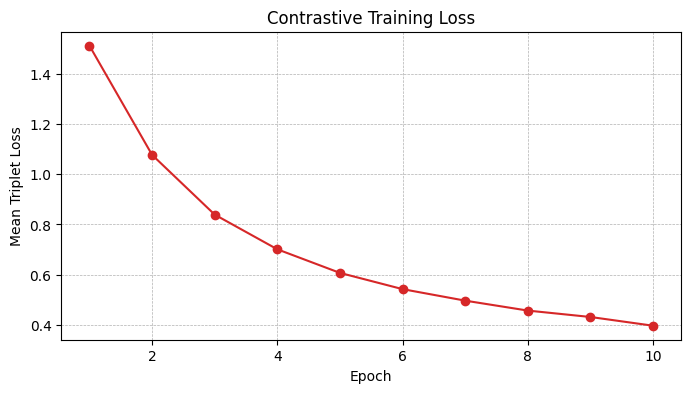

In [2]:
train_loss = pd.read_csv(config.TRAIN_LOSS_PATH)

plt.figure(figsize=(8, 4))
plt.plot(train_loss['epoch'], train_loss['mean_triplet_loss'], marker='o', color='tab:red')
plt.xlabel('Epoch')
plt.ylabel('Mean Triplet Loss')
plt.title('Contrastive Training Loss')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.show()

## Embed the song library with the trained encoder

In [3]:
df_features = load_song_features()
model = load_trained_model(df_features)
embeddings = precompute_embeddings(model, df_features)
embeddings.shape

(13835, 17)

## Recommend songs for an example playlist

In [4]:
# An example playlist — swap in any songs from data/audio_features.csv
playlist = [
    'Coldplay - Fix You',
    'Coldplay - The Scientist',
    'Ed Sheeran - Thinking Out Loud',
    'Adele - Someone Like You',
    'John Mayer - Gravity',
    'Bon Iver - Skinny Love',
    'The Lumineers - Ho Hey',
    'Of Monsters and Men - Little Talks',
    'Vance Joy - Riptide',
    'Passenger - Let Her Go',
]

In [5]:
recommendations = recommend_songs(embeddings, embeddings, playlist)

pd.DataFrame(recommendations[:15], columns=['Recommended song', 'Cosine similarity'])

,Recommended song,Cosine similarity
0,Adele - Hometown Glory (Album),0.978484
1,Adele - Hometown Glory,0.978484
2,Macklemore & Ryan Lewis - Gold - feat. Eighty4...,0.964695
3,Emeli Sandé - Clown,0.959555
4,Lana Del Rey - Summertime Sadness,0.958771
5,Bat For Lashes - Laura,0.958758
6,Edward Sharpe & The Magnetic Zeros - Home,0.957308
7,Edward Sharpe & The Magnetic Zeros - Up From B...,0.957308
8,The Tallest Man On Earth - On Every Page,0.957035
9,Lykke Li - Unrequited Love,0.954736


Recommendations come from the hybridized embedding space: songs whose audio
features (*content*) map close to the playlist's mean embedding, where "close"
was learned from playlist co-occurrence (*collaborative* signal).